In [1]:
import pywt
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import h5py
import os

In [2]:
data_path = "../../UCI/data"
FS = 125
WINDOW_SIZE = 1000

In [6]:
recordings = []

for part in range(1,5):

    file_path = f"{data_path}/Part_{part}.mat"

    f = h5py.File(file_path, "r")

    dataset = f[f"Part_{part}"]


    for i in range(dataset.shape[0]):

        recordings.append(
            (f, dataset[i,0])
        )


print("Total recordings:", len(recordings))

file_handle, recording_ref = recordings[250]

# Dereference the HDF5 reference
recording = file_handle[recording_ref]

Total recordings: 12000


In [9]:
from wavelet import wavelet_denoise, plot_dwt_levels, analyze_wavelet_denoising

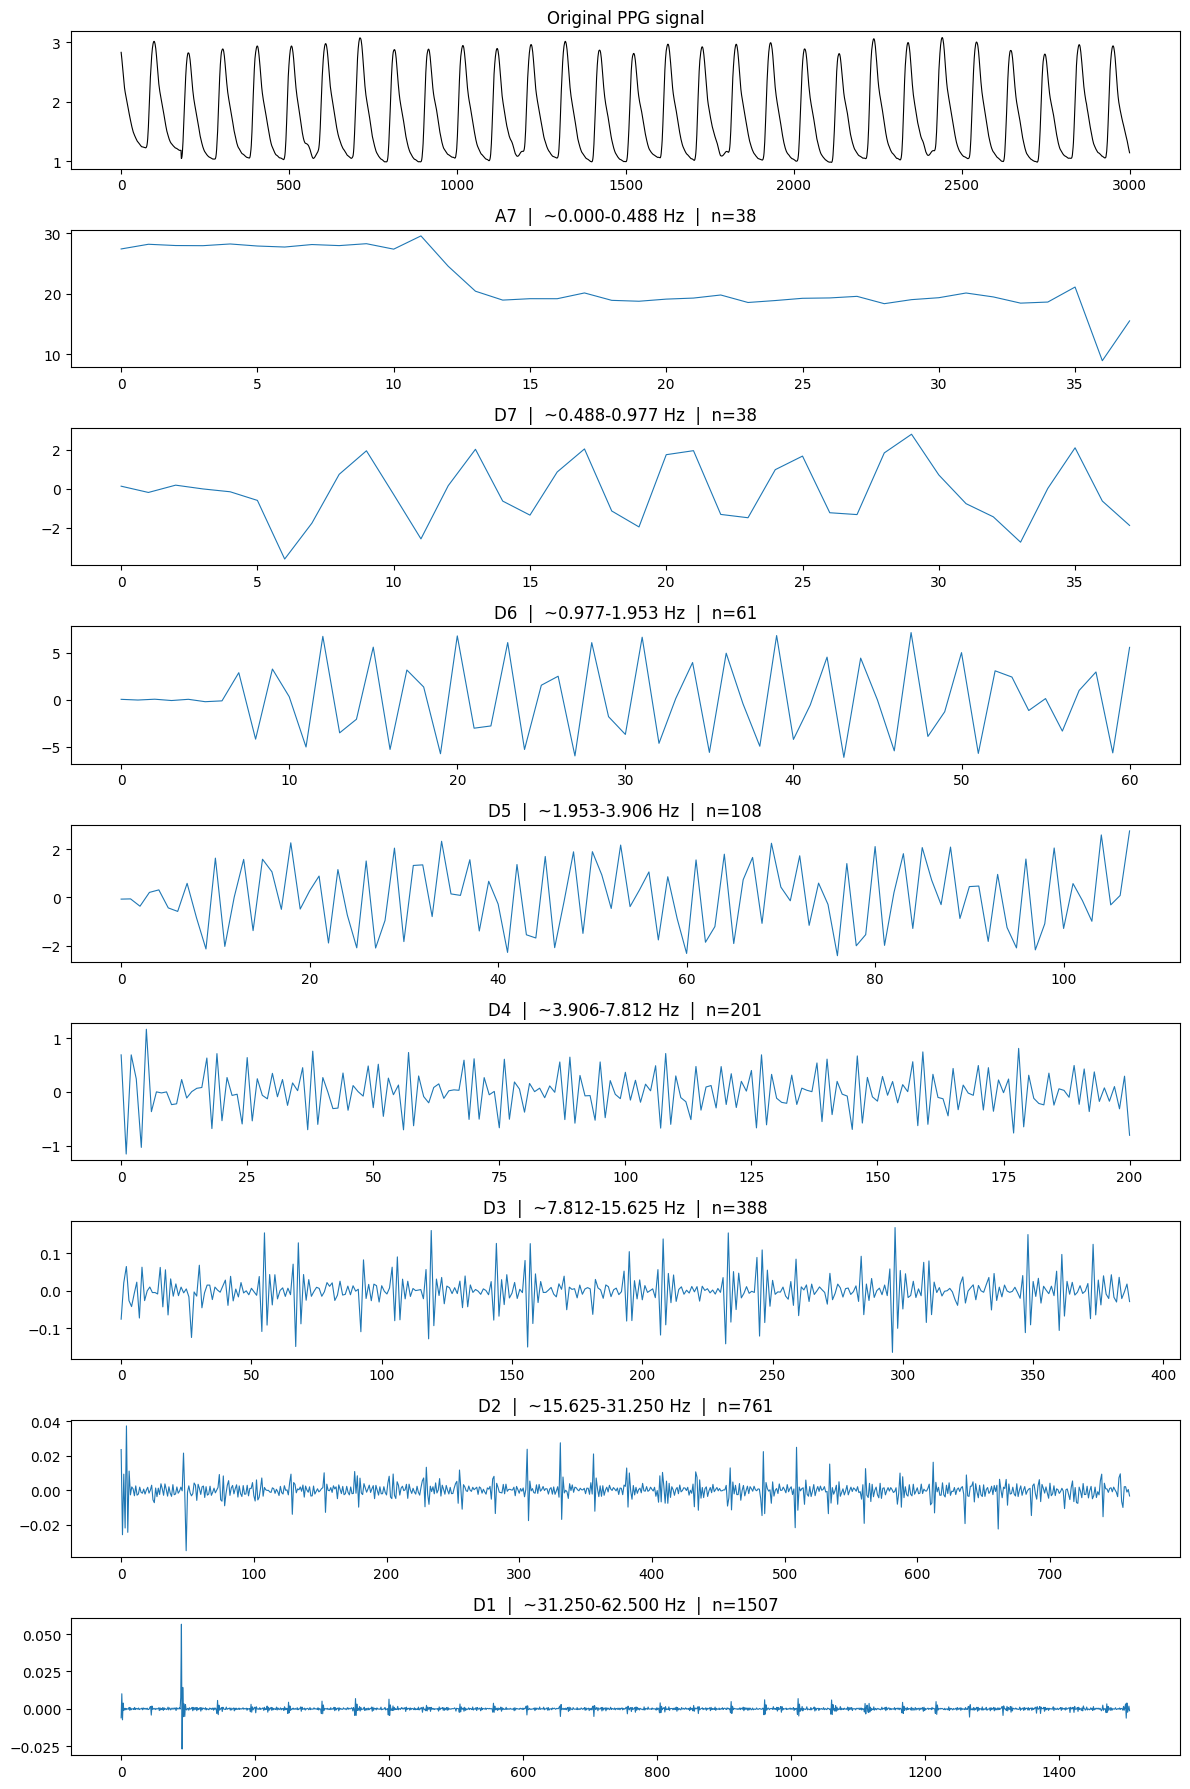

[array([27.43438194, 28.21203023, 28.00142012, 27.97729519, 28.26024914,
        27.92062328, 27.75411992, 28.1663475 , 27.99056592, 28.30532128,
        27.40249067, 29.59747608, 24.57154316, 20.43237972, 18.95919826,
        19.19291319, 19.18779022, 20.14483183, 18.91801082, 18.76926343,
        19.12189769, 19.29592932, 19.80501738, 18.56358796, 18.88569024,
        19.25775335, 19.31857293, 19.57983348, 18.36604323, 19.03554647,
        19.35470458, 20.13462287, 19.48509667, 18.45610561, 18.63573064,
        21.1222548 ,  8.9152933 , 15.51370979]),
 array([ 0.12323683, -0.1983354 ,  0.1763082 , -0.01739138, -0.16354701,
        -0.6066555 , -3.61501354, -1.77153062,  0.73208065,  1.93917921,
        -0.30467445, -2.58086723,  0.14722657,  2.01638409, -0.64133106,
        -1.36167207,  0.85367338,  2.03426626, -1.14945952, -1.96770617,
         1.73950794,  1.94569452, -1.32558532, -1.49580813,  0.97108412,
         1.66756082, -1.23903914, -1.33378024,  1.83165133,  2.7889375 ,
  

In [10]:
ppg = recording[:3000, 0]
plot_dwt_levels(ppg, wavelet="db8", level=7, fs=125)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (71000,)
Denoised shape : (71000,)

Original:
Mean : 1.710811
Std  : 0.643414
Min  : 0.000000
Max  : 3.874878

Denoised:
Mean : -0.000264
Std  : 0.638997
Min  : -1.524395
Max  : 2.047313

Similarity:
Correlation : 0.99301

Residual:
Residual std : 0.075916
Residual / signal std : 11.799%


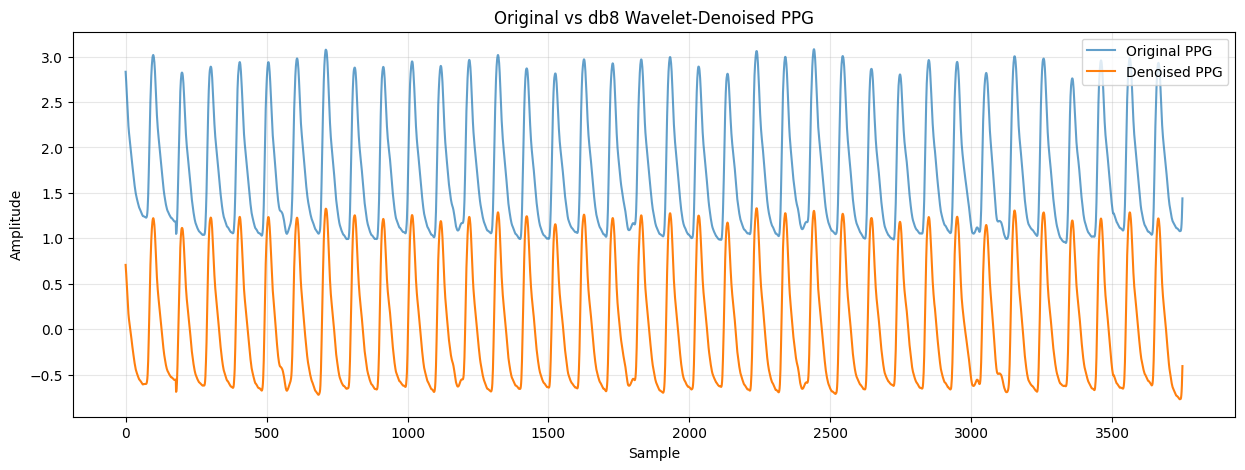

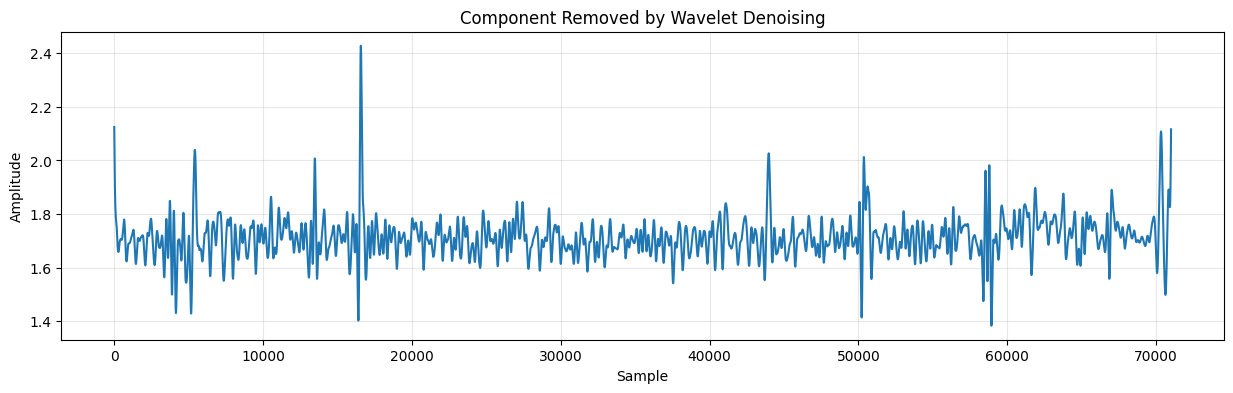

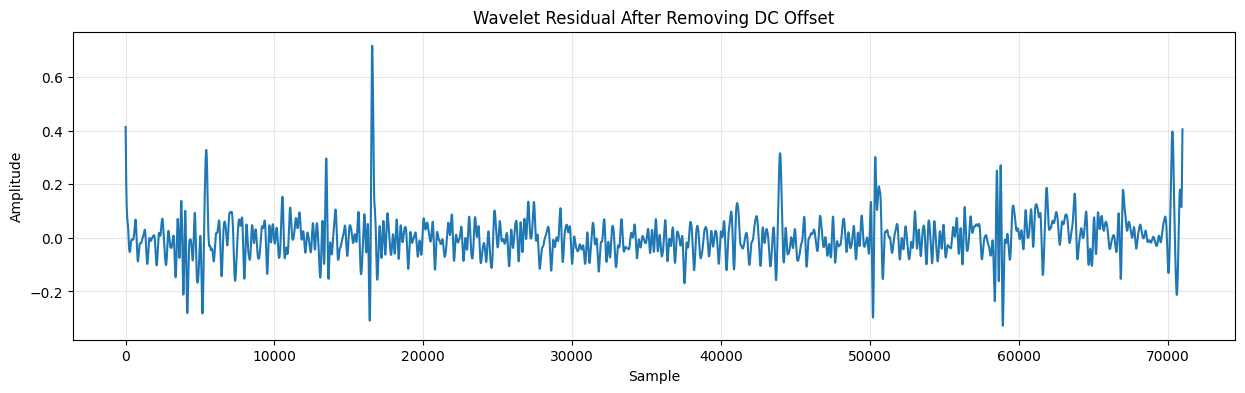

In [11]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise(
    ppg,
    wavelet="db8",
    level=7
)

results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

In [ ]:
DATA_PATH = "../../UCI/data"
WAVELET_PATH = "../../UCI/wavelets_data"

In [ ]:
create_wavelet_dataset(
    input_folder=DATA_PATH,
    output_folder=WAVELET_PATH,
    wavelet="db8",
    level=8
)


Processing Part_1.mat


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../UCI/data/Part_1.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
from scipy.signal import find_peaks

peaks_original, _ = find_peaks(
    ppg,
    distance=50
)

peaks_denoised, _ = find_peaks(
    denoised_ppg,
    distance=50
)

print(
    "Original peaks:",
    len(peaks_original)
)

print(
    "Denoised peaks:",
    len(peaks_denoised)
)

Original peaks: 994
Denoised peaks: 993
